# Chapter 10: Linear regression with multiple predictors

In [2]:
import dataclasses

import arviz
import bambi
import numpy
import pandas

from scipy import stats
from matplotlib import pyplot

/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
_BASE_SEED = "Once again back it's the incredible, rhyme animal, unforgettable D chapter tenemy number 1."

def fresh_prng(seed: str):
    return numpy.random.default_rng(seed=abs(hash(_BASE_SEED + seed)) % (2 ** 32))

### 10.1, Regression with interactions

> Simulate 100 data points from the model,
> $y = b_0 + b_1x + b_2z + b_3xz + error$, with a continuous predictor $x$ and a
> binary predictor $z$, coefficients $b = \{1, 2, -1, -2\}$, and errors drawn
> independently from a normal distribution with mean 0 and standard deviation 3,
> as follows. For each data point $i$, first draw $z_i$ , equally likely to
> take on the values 0 and 1. Then draw $x_i$ from a normal distribution with
> mean $z_i$ and standard deviation 1. Then draw the error from its normal
> distribution and compute $y_i$.
> 
> (a) Display your simulated data as a graph of $y$ vs. $x$, using dots and
>     circles for the points with $z = 0$ and $1$, respectively.
>
> (b) Fit a regression predicting $y$ from $x$ and $z$ with no interaction. Make
> a graph with the data and two parallel lines showing the fitted model.
> 
> (c) Fit a regression predicting $y$ from $x$, $z$, and their interaction. Make
> a graph with the data and two lines showing the fitted model.

In [4]:
rng = fresh_prng('Exercise 10.1')

In [5]:
zs = rng.choice(2, size=100)
xs = rng.normal(loc=zs)
ys = rng.normal(loc=(1 + 2 * xs - zs - 2 * xs * zs), scale=3)

In [6]:
ex1_df = pandas.DataFrame(data={'x': xs, 'z': zs, 'y': ys})

In [7]:
model_linear = bambi.Model('y ~ x + z', ex1_df)
fit_linear = model_linear.fit()
summ_linear = arviz.summary(fit_linear, var_names='~mu')
b0_linear = summ_linear['mean']['Intercept']
b1_linear = summ_linear['mean']['x']
b2_linear = summ_linear['mean']['z']
arviz.summary(fit_linear, var_names='~mu')

Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/venv/ros/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,2.698,0.191,2.344,3.051,0.003,0.003,4304.0,2967.0,1.0
Intercept,1.536,0.377,0.768,2.190,0.005,0.005,4741.0,2918.0,1.0
x,1.015,0.298,0.401,1.540,0.005,0.004,3362.0,2992.0,1.0
z,-2.228,0.620,-3.319,-0.996,0.011,0.009,3388.0,3139.0,1.0


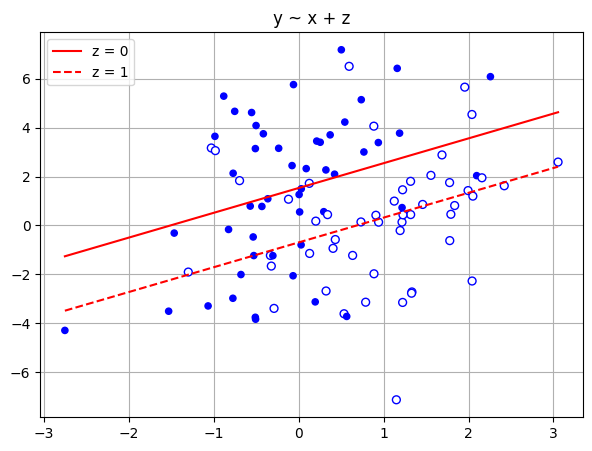

In [8]:
fig = pyplot.figure(figsize=(7, 5))
ax = fig.gca()
ax.grid(zorder=10)
ax.scatter(
    xs,
    ys,
    s=[32 if zi == 1 else 20 for zi in zs],
    c=['w' if zi == 1 else 'b' for zi in zs],
    edgecolors='b',
)
ax.plot(
    [min(xs), max(xs)],
    [b0_linear + b1_linear * min(xs), b0_linear + b1_linear * max(xs)],
    'r-',
    label='z = 0'
)
ax.plot(
    [min(xs), max(xs)],
    [b0_linear + b1_linear * min(xs) + b2_linear, b0_linear + b1_linear * max(xs) + b2_linear],
    'r--',
    label='z = 1'
)
ax.set_title('y ~ x + z')
ax.legend()
ax.set_axisbelow(True)

In [9]:
model_inter = bambi.Model('y ~ x + z + x:z', ex1_df)
fit_inter = model_inter.fit()
summ_inter = arviz.summary(fit_inter, var_names='~mu')
b0_inter = summ_inter['mean']['Intercept']
b1_inter = summ_inter['mean']['x']
b2_inter = summ_inter['mean']['z']
b3_inter = summ_inter['mean']['x:z']
arviz.summary(fit_inter, var_names='~mu')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z, x:z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,2.660,0.195,2.301,3.024,0.003,0.003,4577.0,2972.0,1.0
Intercept,1.581,0.382,0.869,2.285,0.006,0.006,4629.0,3240.0,1.0
x,1.614,0.421,0.832,2.394,0.007,0.007,3527.0,2510.0,1.0
z,-1.767,0.656,-2.924,-0.446,0.009,0.010,5038.0,3325.0,1.0
x:z,-1.127,0.566,-2.193,-0.078,0.010,0.008,3425.0,2866.0,1.0


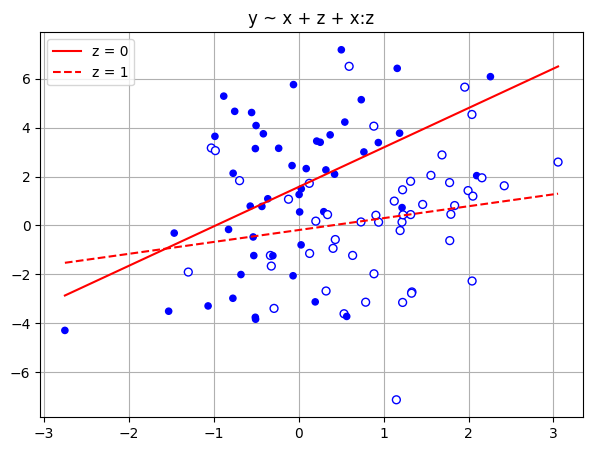

In [10]:
fig = pyplot.figure(figsize=(7, 5))
ax = fig.gca()
ax.grid(zorder=10)
ax.scatter(
    xs,
    ys,
    s=[32 if zi == 1 else 20 for zi in zs],
    c=['w' if zi == 1 else 'b' for zi in zs],
    edgecolors='b',
)
ax.plot(
    [min(xs), max(xs)],
    [b0_inter + b1_inter * min(xs), b0_inter + b1_inter * max(xs)],
    'r-',
    label='z = 0'
)
ax.plot(
    [min(xs), max(xs)],
    [
        b0_inter + (b1_inter + b3_inter) * min(xs) + b2_inter,
        b0_inter + (b1_inter + b3_inter) * max(xs) + b2_inter,
    ],
    'r--',
    label='z = 1'
)
ax.set_title('y ~ x + z + x:z')
ax.legend()
ax.set_axisbelow(True)

## 10.2, Regression with interactions

> Here is the output from a fitted linear regression of outcome $y$ on
> pre-treatment predictor $x$, treatment indicator $z$, and their interaction:

```
            Median MAD_SD
(Intercept) 1.2    0.2
x           1.6    0.4
z           2.7    0.3
x:z         0.7    0.5
 
Auxiliary parameter(s):
      Median MAD_SD`
sigma 0.5    0.0
```

> (a) Write the equation of the estimated regression line of $y$ on $x$ for the
>     treatment group, and the equation of the estimated regression line of $y$
>     on $x$ for the control group.
> 
> (b) Graph with pen on paper the two regression lines, assuming the values of
>     $x$ fall in the range (0, 10). On this graph also include a scatterplot of
>     data (using open circles for treated units and dots for controls) that are
>     consistent with the fitted model.

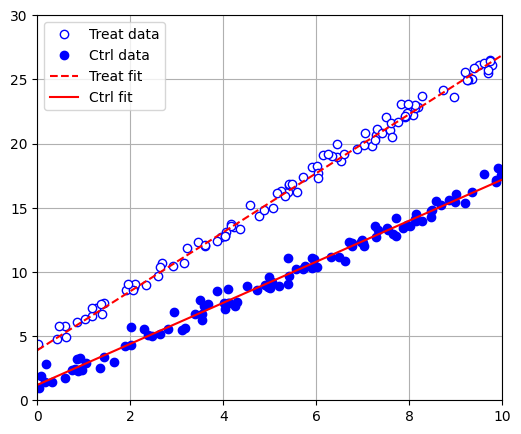

In [11]:
rng = fresh_prng('Exercise 10.2')

x_t = rng.uniform(low=0, high=10, size=100)
y_t = rng.normal(loc=(3.9 + 2.3 * x_t), scale=0.5)
x_c = rng.uniform(low=0, high=10, size=100)
y_c = rng.normal(loc=(1.2 + 1.6 * x_c), scale=0.5)

fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(x_t, y_t, color='w', marker='o', markeredgecolor='b', label='Treat data', linewidth=0)
ax.plot(x_c, y_c, color='b', marker='o', label='Ctrl data', linewidth=0)
ax.plot([0, 10], [3.9, 3.9 + 23], 'r--', label='Treat fit')
ax.plot([0, 10], [1.2, 1.2 + 16], 'r-', label='Ctrl fit')
ax.set_xlim(0, 10)
ax.set_ylim(0, 30)
ax.grid()
ax.legend()
ax.set_axisbelow(True)

## 10.3, Checking statistical significance

> In this exercise and the next, you will simulate two variables that are
> statistically independent of each other to see what happens when we run a
> regression to predict one from the other. Generate 1000 data points from a
> normal distribution with mean 0 and standard deviation 1 by typing
> `var1 <- rnorm(1000,0,1)` in R. Generate another variable in the same way
> (call it `var2`). Run a regression of one variable on the other. Is the slope
> coefficient “statistically significant”? We do not recommend summarizing
> regressions in this way, but it can be useful to understand how this works,
> given that others will do so.

In [12]:
rng = fresh_prng('Exercise 10.3')

In [13]:
var1 = rng.normal(size=1000)
var2 = rng.normal(size=1000)
res = stats.linregress(var1, var2)
print(f'Slope: {res.slope:0.3f}')
print(f'Slope std err: {res.stderr:0.3f}')

Slope: -0.047
Slope std err: 0.033


## 10.4, Simulation study of statistical significance

> Continuing the previous exercise, run a simulation repeating this process 100
> times. This can be done using a loop. From each simulation, save the $z$-score
> (the estimated coefficient of `var1` divided by its standard error). If the
> absolute value of the $z$-score exceeds 2, the estimate is “statistically
> significant.”
> 
> To perform this computation, we start by creating an empty vector of
> $z$-scores filled with missing values (NAs). Another approach is to start with
> `z_scores <- numeric(length=100)`, which would set up a vector of zeroes. In
> general, however, we prefer to initialize with NAs, because then when there is
> a bug in the code, it sometimes shows up as NAs in the final results, alerting
> us to the problem. Here is code to perform the simulation:

```
z_scores <- rep(NA, 100)
for (k in 1:100) {
  var1 <- rnorm(1000, 0, 1)
  var2 <- rnorm(1000, 0, 1)
  fake <- data.frame(var1, var2)
  fit <- stan_glm(var2 ~ var1, data=fake)
  z_scores[k] <- coef(fit)[2] / se(fit)[2]
}
```

> How many of these 100 $z$-scores exceed 2 in absolute value, thus achieving
> the conventional level of statistical significance?

In [14]:
rng = fresh_prng('Exercise 10.4')
statsig_count = 0
for _ in range(100):
    var1 = rng.normal(size=1000)
    var2 = rng.normal(size=1000)
    res = stats.linregress(var1, var2)
    if abs(res.slope) > (2 * res.stderr):
        statsig_count += 1
print(statsig_count)

5


## 10.5, Regression modeling and prediction

> The
> [folder `KidIQ`](https://github.com/avehtari/ROS-Examples/tree/master/KidIQ/)
> contains a subset of the children and mother data discussed
> earlier in the chapter. You have access to children’s test scores at age 3,
> mother’s education, and the mother’s age at the time she gave birth for a
> sample of 400 children.
> 
> (a) Fit a regression of child test scores on mother’s age, display the data
>     and fitted model, check assumptions, and interpret the slope coefficient.
>     Based on this analysis, when do you recommend mothers should give birth?
>     What are you assuming in making this recommendation?
> 
> (b) Repeat this for a regression that further includes mother’s education,
>     interpreting both slope coefficients in this model. Have your conclusions
>     about the timing of birth changed?
> 
> (c) Now create an indicator variable reflecting whether the mother has
>     completed high school or not. Consider interactions between high school
>     completion and mother’s age. Also create a plot that shows the separate
>     regression lines for each high school completion status group.
> 
> (d) Finally, fit a regression of child test scores on mother’s age and
>     education level for the first 200 children and use this model to predict
>     test scores for the next 200. Graphically display comparisons of the
>     predicted and actual scores for the final 200 children.

In [15]:
iq_df = pandas.read_csv('/home/bgawalt/ros/datasets/kidiq.csv')
iq_df.describe()

,kid_score,mom_hs,mom_iq,mom_work,mom_age
count,434.000000,434.000000,434.000000,434.000000,434.000000
mean,86.797235,0.785714,100.000000,2.896313,22.785714
std,20.410688,0.410799,15.000000,1.181394,2.701070
min,20.000000,0.000000,71.037405,1.000000,17.000000
25%,74.000000,1.000000,88.660321,2.000000,21.000000
50%,90.000000,1.000000,97.915254,3.000000,23.000000
75%,102.000000,1.000000,110.272742,4.000000,25.000000
max,144.000000,1.000000,138.893106,4.000000,29.000000


### 10.5(a)

In [16]:
model_age = bambi.Model('kid_score ~ mom_age', iq_df)
fit_age = model_age.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, mom_age]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [17]:
summ_age = arviz.summary(fit_age, var_names='~mu')
b0_age = summ_age['mean']['Intercept']
b1_age = summ_age['mean']['mom_age']
arviz.summary(fit_age, var_names='~mu')

/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,20.378,0.706,19.134,21.781,0.009,0.011,6009.0,3241.0,1.0
Intercept,71.152,8.232,56.494,87.119,0.101,0.122,6685.0,3098.0,1.0
mom_age,0.686,0.358,0.044,1.382,0.004,0.005,6689.0,3393.0,1.0


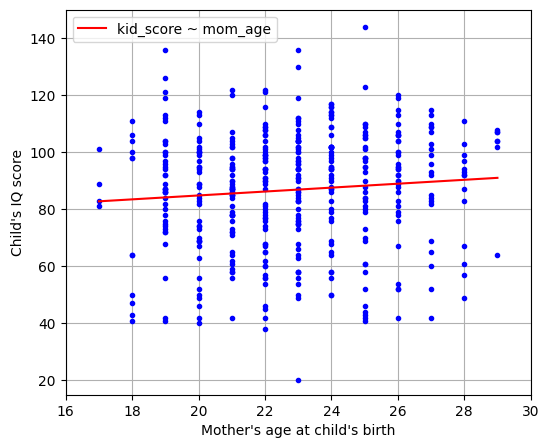

In [18]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(iq_df['mom_age'], iq_df['kid_score'], 'b.')
ax.plot(
    [17, 29],
    [b0_age + b1_age * 17, b0_age + b1_age * 29],
    'r-',
    label='kid_score ~ mom_age',
)
ax.grid()
ax.legend()
ax.set_ylabel("Child's IQ score")
ax.set_xlabel("Mother's age at child's birth")
ax.set_xlim(16, 30)
ax.set_ylim(15, 150)
ax.set_axisbelow(True)

### 10.5(b)

In [19]:
model_lin = bambi.Model('kid_score ~ mom_age + mom_hs', iq_df)
fit_lin = model_lin.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, mom_age, mom_hs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [20]:
summ_lin = arviz.summary(fit_lin, var_names='~mu')
b0_lin = summ_lin['mean']['Intercept']
b1_lin = summ_lin['mean']['mom_age']
b2_lin = summ_lin['mean']['mom_hs']
arviz.summary(fit_lin, var_names='~mu')

/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,19.888,0.674,18.616,21.151,0.008,0.012,6639.0,3084.0,1.0
Intercept,70.546,8.020,55.707,85.928,0.102,0.113,6212.0,3695.0,1.0
mom_age,0.322,0.360,-0.329,1.015,0.005,0.005,5752.0,3522.0,1.0
mom_hs,11.328,2.326,7.097,15.835,0.029,0.035,6430.0,3449.0,1.0


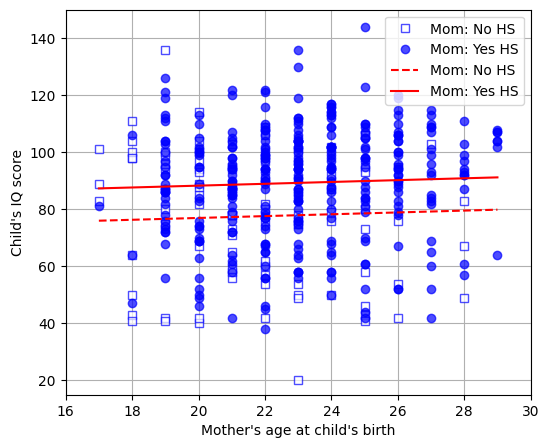

In [21]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(
    iq_df[iq_df['mom_hs'] == 0]['mom_age'],
    iq_df[iq_df['mom_hs'] == 0]['kid_score'],
    markeredgecolor='b',
    linewidth=0,
    marker='s',
    color='w',
    label='Mom: No HS',
    alpha=0.7,
)
ax.plot(
    iq_df[iq_df['mom_hs'] == 1]['mom_age'],
    iq_df[iq_df['mom_hs'] == 1]['kid_score'],
    color='b',
    linewidth=0,
    marker='o',
    label='Mom: Yes HS',
    alpha=0.7,
)
ax.plot(
    [17, 29],
    [b0_lin + b1_lin * 17, b0_lin + b1_lin * 29],
    'r--',
    label='Mom: No HS',
)
ax.plot(
    [17, 29],
    [b0_lin + b1_lin * 17 + b2_lin, b0_lin + b1_lin * 29 + b2_lin],
    'r-',
    label='Mom: Yes HS',
)
ax.grid()
ax.legend()
ax.set_ylabel("Child's IQ score")
ax.set_xlabel("Mother's age at child's birth")
ax.set_xlim(16, 30)
ax.set_ylim(15, 150)
ax.set_axisbelow(True)

### 10.5(c)

In [22]:
model_inter = bambi.Model('kid_score ~ mom_age + mom_hs + mom_age:mom_hs', iq_df)
fit_inter = model_inter.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, mom_age, mom_hs, mom_age:mom_hs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


In [23]:
summ_inter = arviz.summary(fit_inter)
b0_inter = summ_inter['mean']['Intercept']
b1_inter = summ_inter['mean']['mom_age']
b2_inter = summ_inter['mean']['mom_hs']
b3_inter = summ_inter['mean']['mom_age:mom_hs']
arviz.summary(fit_inter)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,19.728,0.660,18.579,21.008,0.013,0.011,2452.0,2040.0,1.0
Intercept,108.590,16.031,78.649,138.342,0.398,0.260,1628.0,1949.0,1.0
mom_age,-1.433,0.736,-2.793,-0.060,0.018,0.012,1604.0,1847.0,1.0
mom_hs,-39.122,18.270,-71.569,-2.525,0.462,0.334,1563.0,1580.0,1.0
mom_age:mom_hs,2.291,0.826,0.725,3.847,0.021,0.015,1533.0,1686.0,1.0


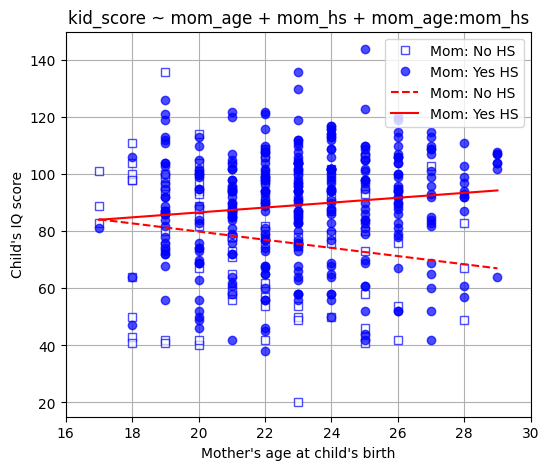

In [24]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(
    iq_df[iq_df['mom_hs'] == 0]['mom_age'],
    iq_df[iq_df['mom_hs'] == 0]['kid_score'],
    markeredgecolor='b',
    linewidth=0,
    marker='s',
    color='w',
    label='Mom: No HS',
    alpha=0.7,
)
ax.plot(
    iq_df[iq_df['mom_hs'] == 1]['mom_age'],
    iq_df[iq_df['mom_hs'] == 1]['kid_score'],
    color='b',
    linewidth=0,
    marker='o',
    label='Mom: Yes HS',
    alpha=0.7,
)
ax.plot(
    [17, 29],
    [b0_inter + b1_inter * 17, b0_inter + b1_inter * 29],
    'r--',
    label='Mom: No HS',
)
ax.plot(
    [17, 29],
    [
        b0_inter + (b1_inter + b3_inter) * 17 + b2_inter,
        b0_inter + (b1_inter + b3_inter) * 29 + b2_inter,
    ],
    'r-',
    label='Mom: Yes HS',
)
ax.grid()
ax.legend()
ax.set_ylabel("Child's IQ score")
ax.set_xlabel("Mother's age at child's birth")
ax.set_xlim(16, 30)
ax.set_ylim(15, 150)
ax.set_title('kid_score ~ mom_age + mom_hs + mom_age:mom_hs')
ax.set_axisbelow(True)

### 10.5(d)

In [25]:
iq_df_train = iq_df[:200]
iq_df_train.describe()

,kid_score,mom_hs,mom_iq,mom_work,mom_age
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,92.980000,0.830000,103.772799,2.965000,23.275000
std,17.604237,0.376575,14.709159,1.153441,2.738039
min,42.000000,0.000000,71.037405,1.000000,17.000000
25%,84.000000,1.000000,92.764078,2.000000,21.000000
50%,95.500000,1.000000,100.937583,3.000000,23.000000
75%,105.000000,1.000000,114.337615,4.000000,25.000000
max,144.000000,1.000000,138.893106,4.000000,29.000000


In [26]:
iq_df_test = iq_df[200:]
iq_df_test.describe()

,kid_score,mom_hs,mom_iq,mom_work,mom_age
count,234.000000,234.000000,234.000000,234.000000,234.000000
mean,81.512821,0.747863,96.775385,2.837607,22.367521
std,21.181260,0.435170,14.514980,1.204122,2.602733
min,20.000000,0.000000,74.230245,1.000000,17.000000
25%,67.250000,0.250000,85.033956,2.000000,21.000000
50%,84.000000,1.000000,93.032053,3.000000,22.000000
75%,97.000000,1.000000,107.150411,4.000000,24.000000
max,136.000000,1.000000,136.577170,4.000000,29.000000


In [27]:
model_200 = bambi.Model('kid_score ~ mom_age + mom_hs + mom_age:mom_hs', iq_df_train)
fit_200 = model_200.fit()
arviz.summary(fit_200)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, mom_age, mom_hs, mom_age:mom_hs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,17.586,0.903,15.922,19.245,0.019,0.016,2147.0,2338.0,1.00
Intercept,115.433,21.536,74.842,155.246,0.619,0.423,1218.0,1614.0,1.00
mom_age,-1.186,0.982,-2.988,0.740,0.028,0.019,1199.0,1648.0,1.00
mom_hs,-37.233,24.435,-83.949,6.175,0.744,0.508,1088.0,1530.0,1.01
mom_age:mom_hs,1.844,1.095,-0.180,3.922,0.034,0.023,1074.0,1386.0,1.01


In [28]:
@dataclasses.dataclass(frozen=True)
class KidIQPrediction:
    actual: float
    p025: float
    p25: float
    p50: float
    p75: float
    p975: float

    def plot(self, ax: pyplot.Axes):
        ax.plot([self.actual, self.actual], [self.p025, self.p975], 'b-', linewidth=1, alpha=0.7)
        ax.plot([self.actual, self.actual], [self.p25, self.p75], 'b-', linewidth=3, alpha=0.7)
        ax.plot([self.actual,], [self.p50,], 'b.')

In [46]:
kiq_preds = []
rng = fresh_prng("Exercise 10.5(d)")
for _, test_row in iq_df_test.iterrows():
    preds = []
    for chain in range(4):
        sims = fit_200.posterior.sel(chain=chain).to_dataframe()
        for _, sim_row in sims.iterrows():
            preds.append(
                sim_row["Intercept"] +
                sim_row["mom_age"] * test_row["mom_age"] +
                sim_row["mom_hs"] * test_row["mom_hs"] +
                sim_row["mom_age:mom_hs"] * test_row["mom_age"] * test_row["mom_hs"] +
                rng.normal(0, sim_row["sigma"])
            )
    qs = numpy.quantile(preds, q=[0.025, 0.25, 0.5, 0.75, 0.975])
    kiq_preds.append(KidIQPrediction(
        actual=test_row["kid_score"],
        p025=qs[0],
        p25=qs[1],
        p50=qs[2],
        p75=qs[3],
        p975=qs[4],
    ))

Text(0, 0.5, 'Predicted Child IQ')

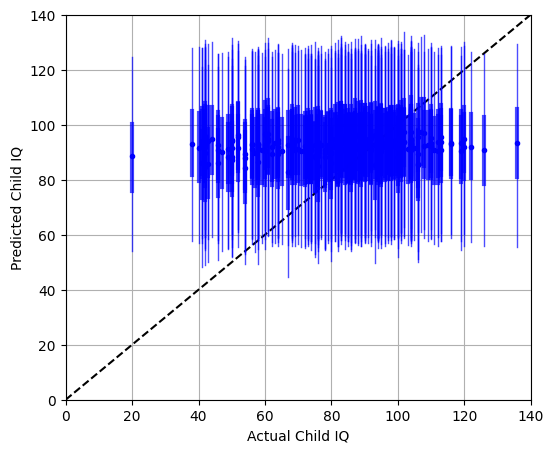

In [47]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot([0, 140], [0, 140], 'k--')
for kiqp in kiq_preds:
    kiqp.plot(ax)
ax.grid()
ax.set_xlabel('Actual Child IQ')
ax.set_xlim(0, 140)
ax.set_ylim(0, 140)
ax.set_ylabel('Predicted Child IQ')

## 10.6, Regression models with interactions:

> [The folder `Beauty` contains](https://github.com/avehtari/ROS-Examples/tree/master/Beauty/data)
> data (use file `beauty.csv`) from Hamermesh and Parker (2005) on student
> evaluations of instructors’ beauty and teaching quality for several courses at
> the University of Texas. The teaching evaluations were conducted at the end
> of the semester, and the beauty judgments were made later, by six students who
> had not attended the classes and were not aware of the course evaluations.
> 
> (a) Run a regression using beauty (the variable `beauty`) to predict course
>     evaluations (`eval`), adjusting for various other predictors. Graph the
>     data and fitted model, and explain the meaning of each of the coefficients
>     along with the residual standard deviation. Plot the residuals versus
>     fitted values.
> 
> (b) Fit some other models, including beauty and also other predictors.
>     Consider at least one model with interactions. For each model, explain the
>     meaning of each of its estimated coefficients.
> 
> See also Felton, Mitchell, and Stinson (2003) for more on this topic.

In [31]:
beauty_df = pandas.read_csv('/home/bgawalt/ros/datasets/beauty.csv')
beauty_df.describe()

,eval,beauty,female,age,minority,nonenglish,lower,course_id
count,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000
mean,3.998272,-0.088349,0.421166,48.365011,0.138229,0.060475,0.339093,4.987041
std,0.554866,0.788648,0.494280,9.802742,0.345513,0.238623,0.473913,8.658995
min,2.100000,-1.538843,0.000000,29.000000,0.000000,0.000000,0.000000,0.000000
25%,3.600000,-0.744618,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,-0.156363,0.000000,48.000000,0.000000,0.000000,0.000000,0.000000
75%,4.400000,0.457253,1.000000,57.000000,0.000000,0.000000,1.000000,6.000000
max,5.000000,1.881674,1.000000,73.000000,1.000000,1.000000,1.000000,30.000000


### 10.6(a)

In [32]:
beauty_linear = bambi.Model('eval ~ beauty + female + age + minority + nonenglish + lower', beauty_df)
fit_beauty_linear = beauty_linear.fit()
arviz.summary(fit_beauty_linear)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, beauty, female, age, minority, nonenglish, lower]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.532,0.018,0.499,0.566,0.000,0.000,4755.0,2835.0,1.0
Intercept,4.197,0.143,3.940,4.483,0.002,0.002,4021.0,3295.0,1.0
beauty,0.140,0.033,0.079,0.201,0.000,0.001,4939.0,3163.0,1.0
female,-0.199,0.052,-0.298,-0.101,0.001,0.001,4477.0,3355.0,1.0
age,-0.002,0.003,-0.007,0.003,0.000,0.000,4103.0,3537.0,1.0
minority,-0.071,0.076,-0.205,0.078,0.001,0.001,4706.0,3615.0,1.0
nonenglish,-0.274,0.111,-0.477,-0.061,0.002,0.002,4698.0,3545.0,1.0
lower,0.098,0.053,-0.003,0.194,0.001,0.001,4776.0,3492.0,1.0


In [38]:
summ_beauty_linear = arviz.summary(fit_beauty_linear)
b0_beauty_linear = (
    summ_beauty_linear['mean']['Intercept'] +
    48.4 * summ_beauty_linear['mean']['age']
)
b1_beauty_linear = summ_beauty_linear['mean']['beauty']
b2_beauty_linear = summ_beauty_linear['mean']['female']

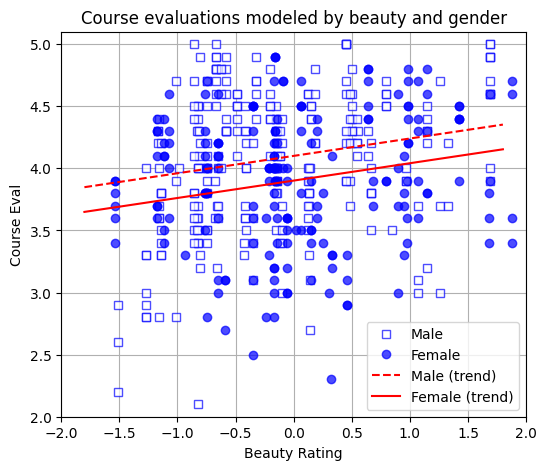

In [42]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(
    beauty_df[beauty_df['female'] == 0]['beauty'],
    beauty_df[beauty_df['female'] == 0]['eval'],
    markeredgecolor='b',
    linewidth=0,
    marker='s',
    color='w',
    label='Male',
    alpha=0.7,
)
ax.plot(
    beauty_df[beauty_df['female'] == 1]['beauty'],
    beauty_df[beauty_df['female'] == 1]['eval'],
    color='b',
    linewidth=0,
    marker='o',
    label='Female',
    alpha=0.7,
)
ax.plot(
    [-1.8, 1.8],
    [
        b0_beauty_linear - b1_beauty_linear * 1.8,
        b0_beauty_linear + b1_beauty_linear * 1.8,
    ],
    'r--',
    label='Male (trend)',
)
ax.plot(
    [-1.8, 1.8],
    [
        b0_beauty_linear - b1_beauty_linear * 1.8 + b2_beauty_linear,
        b0_beauty_linear + b1_beauty_linear * 1.8 + b2_beauty_linear,
    ],
    'r-',
    label='Female (trend)',
)
ax.grid()
ax.legend()
ax.set_ylabel("Course Eval")
ax.set_xlabel("Beauty Rating")
ax.set_xlim(-2, 2)
ax.set_ylim(2, 5.1)
ax.set_title('Course evaluations modeled by beauty and gender')
ax.set_axisbelow(True)

### 10.6(b)

In [48]:
beauty_inter = bambi.Model(
    'eval ~ beauty + female + beauty:female + age + minority + nonenglish + lower',
    beauty_df,
)
fit_beauty_inter = beauty_inter.fit()
arviz.summary(fit_beauty_inter)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, beauty, female, beauty:female, age, minority, nonenglish, lower]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.531,0.018,0.498,0.564,0.000,0.000,6108.0,3047.0,1.0
Intercept,4.178,0.145,3.899,4.439,0.002,0.002,5064.0,3229.0,1.0
beauty,0.189,0.046,0.104,0.278,0.001,0.001,5001.0,3220.0,1.0
female,-0.204,0.054,-0.305,-0.106,0.001,0.001,5913.0,2851.0,1.0
beauty:female,-0.104,0.066,-0.223,0.020,0.001,0.001,4787.0,3370.0,1.0
age,-0.002,0.003,-0.007,0.003,0.000,0.000,4821.0,3269.0,1.0
minority,-0.045,0.078,-0.182,0.103,0.001,0.001,5600.0,3267.0,1.0
nonenglish,-0.292,0.111,-0.493,-0.076,0.001,0.002,5669.0,2975.0,1.0
lower,0.093,0.055,-0.011,0.196,0.001,0.001,6196.0,3075.0,1.0


In [49]:
summ_beauty_inter = arviz.summary(fit_beauty_inter)
b0_beauty_inter = (
    summ_beauty_inter['mean']['Intercept'] +
    48.4 * summ_beauty_inter['mean']['age']
)
b1_beauty_inter = summ_beauty_inter['mean']['beauty']
b2_beauty_inter = summ_beauty_inter['mean']['female']
b3_beauty_inter = summ_beauty_inter['mean']['beauty:female']

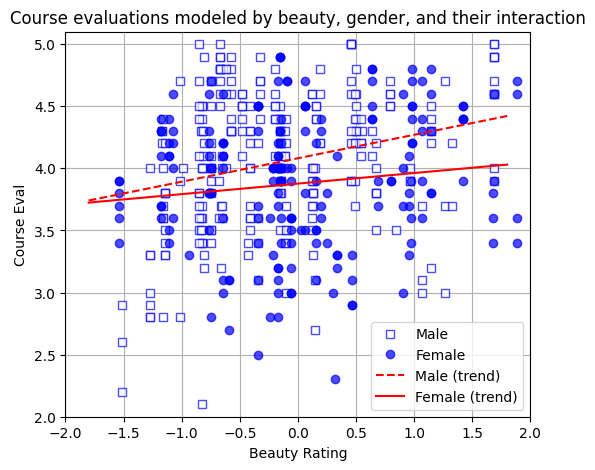

In [50]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(
    beauty_df[beauty_df['female'] == 0]['beauty'],
    beauty_df[beauty_df['female'] == 0]['eval'],
    markeredgecolor='b',
    linewidth=0,
    marker='s',
    color='w',
    label='Male',
    alpha=0.7,
)
ax.plot(
    beauty_df[beauty_df['female'] == 1]['beauty'],
    beauty_df[beauty_df['female'] == 1]['eval'],
    color='b',
    linewidth=0,
    marker='o',
    label='Female',
    alpha=0.7,
)
ax.plot(
    [-1.8, 1.8],
    [
        b0_beauty_inter - b1_beauty_inter * 1.8,
        b0_beauty_inter + b1_beauty_inter * 1.8,
    ],
    'r--',
    label='Male (trend)',
)
ax.plot(
    [-1.8, 1.8],
    [
        b0_beauty_inter - (b1_beauty_inter + b3_beauty_inter) * 1.8 + b2_beauty_inter,
        b0_beauty_inter + (b1_beauty_inter + b3_beauty_inter) * 1.8 + b2_beauty_inter,
    ],
    'r-',
    label='Female (trend)',
)
ax.grid()
ax.legend()
ax.set_ylabel("Course Eval")
ax.set_xlabel("Beauty Rating")
ax.set_xlim(-2, 2)
ax.set_ylim(2, 5.1)
ax.set_title('Course evaluations modeled by beauty, gender, and their interaction')
ax.set_axisbelow(True)

## 10.7, Predictive simulation for linear regression

> Take one of the models from the previous exercise.
> 
> (a) Instructor A is a 50-year-old woman who is a native English speaker and
>     has a beauty score of -1. Instructor B is a 60-year-old man who is a
>     native English speaker and has a beauty score of -0.5. Simulate 1000
>     random draws of the course evaluation rating of these two instructors. In
>     your simulation, use `posterior_predict` to account for the uncertainty in
>     the regression parameters as well as predictive uncertainty.
> 
> (b) Make a histogram of the difference between the course evaluations for A
>     and B. What is the probability that A will have a higher evaluation?

In [53]:
rng = fresh_prng("Exercise 10.7")

man_preds = []
woman_preds = []
kiq_preds = []
for chain in range(4):
    sims = fit_beauty_inter.posterior.sel(chain=chain).to_dataframe()
    for _, sim_row in sims.iterrows():
        man_preds.append(
            sim_row["Intercept"] +
            sim_row["beauty"] * (-0.5) +
            sim_row["age"] * 60 +
            rng.normal(0, sim_row["sigma"])
        )
        woman_preds.append(
            sim_row["Intercept"] +
            sim_row["beauty"] * (-1) +
            sim_row["female"] +
            sim_row["beauty:female"] * (-1) +
            sim_row["age"] * 50 +
            rng.normal(0, sim_row["sigma"])
        )

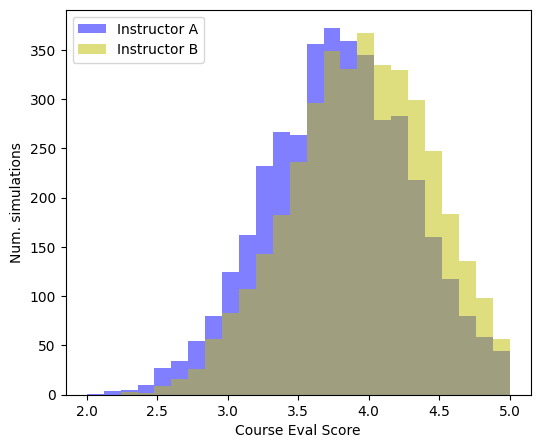

In [61]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.hist(woman_preds, bins=25, range=(2, 5), label='Instructor A', color='b', alpha=0.5)
ax.hist(man_preds, bins=25, range=(2, 5), label='Instructor B', color='y', alpha=0.5)
ax.set_xlabel('Course Eval Score')
ax.set_ylabel('Num. simulations')
ax.legend(loc='upper left')

41.8 pct chance Instructor A has a higher eval


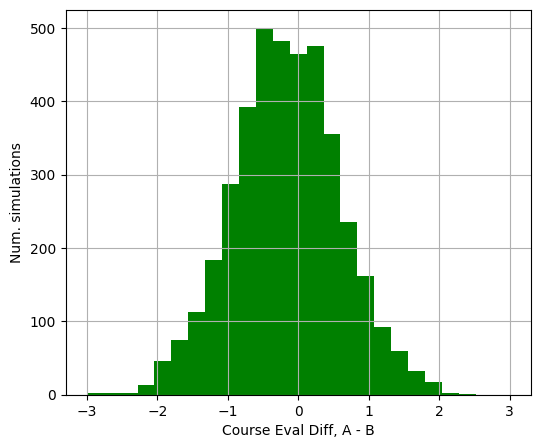

In [66]:
diffs = [wi - mi for (wi, mi) in zip(woman_preds, man_preds)]
pos_share = sum(1 if di > 0 else 0 for di in diffs) / len(diffs)
print(f'{100 * pos_share} pct chance Instructor A has a higher eval')

fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.hist(diffs, bins=25, range=(-3, 3), color='g')
ax.set_xlabel('Course Eval Diff, A - B')
ax.set_ylabel('Num. simulations')
ax.grid()